#**Parcial**

Le han solicitado que ayude a las autoridades locales a hacer la planeación de la atención y prevención de los accidentes de tránsito en la ciudad de Medellin, para lo cual le han suministrado los datos de los accidentes de tránsito que se han presentado en el periodo 2014-2020.

Se espera que informe:
1. Dónde ubicar:
*   los agentes de tránsito
*   las ambulancias
2. Los horarios y el personal qué debe estar disponible para atender los eventos. Teniendo en cuenta en qué horarios, días y fechas particulares se presentan mayor accidentalidad y de qué tipo.
3. Se espera que tenga en cuenta los años y la estacionalidad al momento de analizar la accidentalidad.
4. Recomendaciones para prevenir los accidentes de tránsito.


**Se debe entregar el reporte hasta el lunes 7 de septiembre, incluyendo el código y todos los análisis correspondientes.**

**Variables de la base de datos**


| Variable             | Interpretación         |
| -------------------- | ------------------------------ |
| `NRO_RADICADO`       | Identificador del incidente    |
| `Latitud`            | Ubicación geográfica           |
| `Longitud`           | Ubicación geográfica           |
| `CLASE_ACCIDENTE`    | Tipo o clase del accidente     |
| `DIRECCION`          | Ubicación textual              |
| `CBML`               | Código de ubicación            |
| `Gravedad Incidente` | Nivel o gravedad del incidente |
| `nombre comuna`      | Comuna                         |
| `Barrio`             | Barrio                         |
| `Diseño`             | Característica del lugar o vía |
| `Año`                | Año del accidente              |
| `FECHA_ACCIDENTE`    | Fecha                          |
| `HORA_ACCIDENTE`     | Hora                           |
| `codigo comuna`      | Código de comuna               |
| `Comuna`             | Nombre/código de comuna        |


1. Importar librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df =pd.read_excel("/content/drive/MyDrive/Aprendizaje no supervisado/Incidentes2014_2020.xlsx" )
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,NRO_RADICADO,Latitud,Longitud,CLASE_ACCIDENTE,DIRECCION,CBML,Gravedad Incidente,nombre comuna,Barrio,Diseño,Año,FECHA_ACCIDENTE,HORA_ACCIDENTE,codigo comuna,Comuna
0,1423828,6.219016,-75.602726,Choque,CR 80 CL 8,1611,Con heridos,Belén,Loma de los Bernal,Tramo de via,2014,2014-01-01,02:20:00,16,16 - Belén
1,1423839,6.260009,-75.568185,Atropello,CR 53 CL 61,1003,Con heridos,La Candelaria,Jesús Nazareno,Tramo de via,2014,2014-01-01,00:50:00,10,10 - La Candelaria
2,1423840,6.264765,-75.549943,Atropello,CR 39 CL 70,0308,Con heridos,Manrique,Manrique Oriental,Tramo de via,2014,2014-01-01,01:00:00,3,03 - Manrique
3,1423849,6.234327,-75.607611,Atropello,CL 32 CR 84,1617,Con heridos,Belén,Las Mercedes,Tramo de via,2014,2014-01-01,00:37:00,16,16 - Belén
4,1423890,6.300243,-75.579644,Caida Ocupante,CR 80 CL 101,0603,Con heridos,Doce De Octubre,Doce de Octubre No.2,Tramo de via,2014,2014-01-01,10:40:00,6,06 - Doce de Octubre


2. Exploracion de variables y limpieza de datos

Cuantos registros y variables tiene esta base de datos

In [ ]:
df.shape

(288983, 15)

la base de datos tiene 15 columnas y 288983 filas

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288983 entries, 0 to 288982
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   NRO_RADICADO        288980 non-null  object        
 1   Latitud             288449 non-null  float64       
 2   Longitud            288449 non-null  float64       
 3   CLASE_ACCIDENTE     288976 non-null  object        
 4   DIRECCION           288983 non-null  object        
 5   CBML                266383 non-null  object        
 6   Gravedad Incidente  288983 non-null  object        
 7   nombre comuna       288983 non-null  object        
 8   Barrio              265511 non-null  object        
 9   Diseño              288198 non-null  object        
 10  Año                 288983 non-null  int64         
 11  FECHA_ACCIDENTE     288983 non-null  datetime64[ns]
 12  HORA_ACCIDENTE      288983 non-null  object        
 13  codigo comuna       288983 no

Analizar valores faltantes

In [ ]:
df.isnull().sum()

,0
NRO_RADICADO,3
Latitud,534
Longitud,534
CLASE_ACCIDENTE,7
DIRECCION,0
CBML,22600
Gravedad Incidente,0
nombre comuna,0
Barrio,23472
Diseño,785


In [ ]:
faltantes = pd.DataFrame({
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().sum() / len(df)) * 100
})

faltantes.sort_values(
    by="Valores faltantes",
    ascending=False
)

,Valores faltantes,Porcentaje (%)
Barrio,23472,8.122277
CBML,22600,7.820529
Diseño,785,0.271642
Longitud,534,0.184786
Latitud,534,0.184786
CLASE_ACCIDENTE,7,0.002422
NRO_RADICADO,3,0.001038
Gravedad Incidente,0,0.000000
DIRECCION,0,0.000000
nombre comuna,0,0.000000


no puedo tener registros con coordenadas faltantes porque esto es lo que me va a ayudar a determinar en gran manera a que direcciones hay que mandar los agentes de transito y las ambulancias, por lo tanto voy a borrar estos registros. Los valores faltantes en las otras variables no los voy a borrar porque aunque me dan informacion de los accidentes no son determinantes para el objetivo que se debe lograr con el analisis y su porcentaje no es muy alto en el total de registros

Después de eliminar los registros con valores faltantes en `Latitud` o `Longitud`, vamos a verificar cómo quedaron los valores faltantes en el DataFrame.

In [ ]:
df.dropna(subset=['Latitud', 'Longitud'], inplace=True)

In [ ]:
print('Valores faltantes después de la eliminación:')
print(df.isnull().sum().sort_values(ascending=False))

Valores faltantes después de la eliminación:
Barrio                22939
CBML                  22067
Diseño                  785
CLASE_ACCIDENTE           7
NRO_RADICADO              3
Longitud                  0
Latitud                   0
Gravedad Incidente        0
DIRECCION                 0
nombre comuna             0
Año                       0
FECHA_ACCIDENTE           0
HORA_ACCIDENTE            0
codigo comuna             0
Comuna                    0
dtype: int64


revisar si existen coordenadas duplicadas para ver que tantos accidentes ocurrieron en el mismo lugar

In [ ]:
df[["Latitud", "Longitud"]].duplicated().sum()

np.int64(252980)

In [ ]:
df[["Latitud", "Longitud"]].drop_duplicates().shape[0] #y cuantas ubicaciones unicas hay

35469

In [ ]:
#ubicaciones donde se repiten mas accidentes
ubicaciones_frecuentes = (
    df.groupby(["Latitud", "Longitud"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

ubicaciones_frecuentes

,,0
Latitud,Longitud,
6.221806,-75.703816,16499
6.221415,-75.703776,5795
6.276299,-75.573364,722
6.273389,-75.593021,676
6.248048,-75.580468,633
6.263846,-75.596633,629
6.246884,-75.575211,629
6.276171,-75.572869,608
6.276081,-75.570616,560


6.221806	-75.703816	16499

6.221415	-75.703776	5795

estas son coordenadas fantasmas porque cuando se ponen en el mapa te llevan a una ubicacion lejos en la que no hay calles, estas coordenadas serian como OUTLIERS o valores atipicos porque me van a modificar todo el analisis


In [ ]:
# Eliminar registros con coordenadas fantasma
df = df[
    ~(
        ((df["Latitud"] == 6.221806) & (df["Longitud"] == -75.703816)) |
        ((df["Latitud"] == 6.221415) & (df["Longitud"] == -75.703776))
    )
]


Ahora vamos a analizar las DIRECCIONES, cuantas hay diferentes y cuales son las mas frecuentes

In [ ]:
df["DIRECCION"].nunique()

40188

In [ ]:
df["DIRECCION"].value_counts().head(20)

,count
DIRECCION,
CR 999 CL 999,1978
CR 64 C CL 78,1241
CL 999 CR 999,1175
CR 57 CL 44,890
CR 64 C CL 67,810
CR 80 CL 50,728
CR 80 CL 65,659
CR 52 CL 10,624
CR 48 CL 10,613


aca hay algo importante:

Estas dos direcciones CR 999 CL 999 , CL 999 CR 999  no parecen direcciónes reales normales. Podrian ser valores atipicos porque no me llevan a ninguna direccion exacta, estos registros hay que borrarlos porque tambien van a perjudicar el analisis


In [ ]:
# Eliminar las dos direcciones inexistentes

direcciones_invalidas = [
    "CR 999 CL 999",
    "CL 999 CR 999"
]

df = df[~df["DIRECCION"].isin(direcciones_invalidas)]

print("Dimensiones después de la limpieza:", df.shape)

Dimensiones después de la limpieza: (285296, 15)


como quedo la estructura general de las variables despues de la limpieza

In [ ]:
print("DIMENSIONES DEL DATASET:")
print(df.shape)

print("\n" + "="*70)

print("INFORMACIÓN DE LAS VARIABLES:")
print(df.info())

print("\n" + "="*70)

print("VALORES FALTANTES:")
print(df.isnull().sum().sort_values(ascending=False))

DIMENSIONES DEL DATASET:
(285296, 15)

INFORMACIÓN DE LAS VARIABLES:
<class 'pandas.core.frame.DataFrame'>
Index: 285296 entries, 0 to 288982
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   NRO_RADICADO        285293 non-null  object        
 1   Latitud             285296 non-null  float64       
 2   Longitud            285296 non-null  float64       
 3   CLASE_ACCIDENTE     285289 non-null  object        
 4   DIRECCION           285296 non-null  object        
 5   CBML                266253 non-null  object        
 6   Gravedad Incidente  285296 non-null  object        
 7   nombre comuna       285296 non-null  object        
 8   Barrio              265510 non-null  object        
 9   Diseño              284511 non-null  object        
 10  Año                 285296 non-null  int64         
 11  FECHA_ACCIDENTE     285296 non-null  datetime64[ns]
 12  HORA_ACCIDENTE      28

Modelo 1: K-Means

para identificar zonas de concentración de accidentes para apoyar la decision sobre la ubicacion de los agentes de transito y las ambulancias

Las variables Latitud y Longitud permiten identificar la ubicación espacial de cada accidente y agrupar los que se encuentran geográficamente cercanos.
Se seleccionan únicamente estas dos variables para este primer modelo porque el objetivo es identificar zonas geográficas de concentración de accidentes.

crear la base para el modelo

In [ ]:
# Selección de las variables para el primer modelo

data_kmeans = df[["Latitud", "Longitud"]].copy()

data_kmeans.head()

,Latitud,Longitud
0,6.219016,-75.602726
1,6.260009,-75.568185
2,6.264765,-75.549943
3,6.234327,-75.607611
4,6.300243,-75.579644


en este caso de K means no se estandarizan las variables porque son coordenadas geograficas

metodo del codo

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(data_kmeans)

    inertia.append(kmeans.inertia_)

    print(f"K={k} - Inercia: {kmeans.inertia_}")

K=1 - Inercia: 620.083360593381
K=2 - Inercia: 294.1992730778468
K=3 - Inercia: 166.66482578382713
K=4 - Inercia: 125.66250347282143
K=5 - Inercia: 90.31209287823228
K=6 - Inercia: 71.9868523574804
K=7 - Inercia: 60.7358720758159
K=8 - Inercia: 51.512331106021534
K=9 - Inercia: 44.951395380067986
K=10 - Inercia: 39.780505620278824


grafico

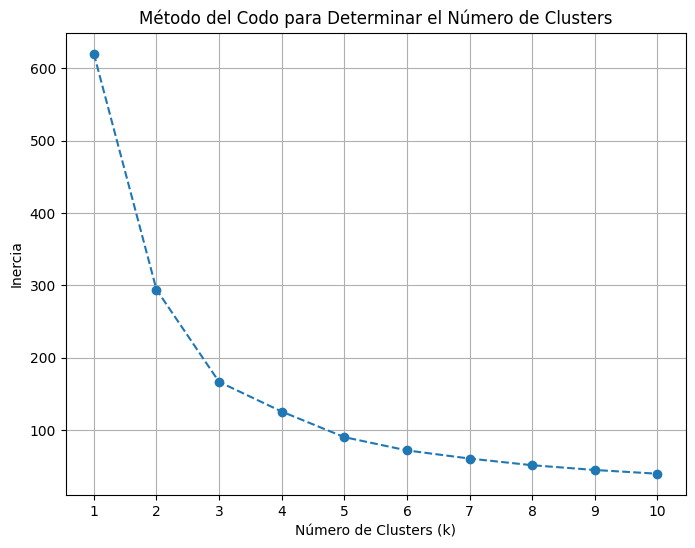

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    K_range,
    inertia,
    marker='o',
    linestyle='--'
)

plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Determinar el Número de Clusters')

plt.xticks(K_range)
plt.grid(True)

plt.show()

este metodo sugiere entre 3 a 4 clusters

coeficiente de silueta (lo hice solo con 10000 registros como base porque si lo hago con todos se demora mucho cargando)

In [ ]:
from sklearn.metrics import silhouette_score

silueta = []

n_clusters = range(2, 11)

for k in n_clusters:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(data_kmeans)

    score = silhouette_score(
        data_kmeans,
        kmeans.labels_,
        sample_size=10000,
        random_state=42
    )

    silueta.append(score)

    print(f"K={k} - Silhouette Score: {score}")

K=2 - Silhouette Score: 0.6898124230655859
K=3 - Silhouette Score: 0.41801629070394464
K=4 - Silhouette Score: 0.39014425920004375
K=5 - Silhouette Score: 0.4369892074604109
K=6 - Silhouette Score: 0.4541061338889205
K=7 - Silhouette Score: 0.44227564719301427
K=8 - Silhouette Score: 0.4107800571852734
K=9 - Silhouette Score: 0.41144750790770096
K=10 - Silhouette Score: 0.41273212788870006


K = 2 tiene el mejor resultado: 0.6898

al dividir los accidentes geográficamente en 2 clusters, los grupos están mucho mejor definidos y separados segun este modelo de k means y aunque en el anterior grafico mostraba de 3 a 4 este valor del coeficiente de silueta es muy exacto yesta por encima de los otros numeros de clusters

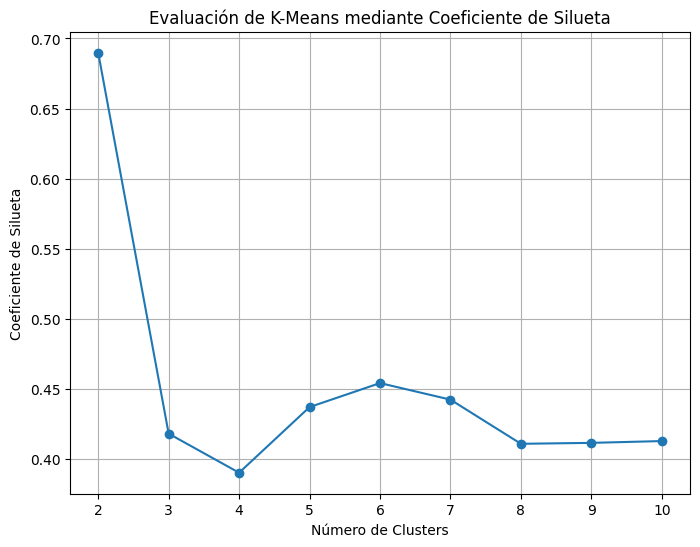

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    list(n_clusters),
    silueta,
    marker='o'
)

plt.xlabel('Número de Clusters')
plt.ylabel('Coeficiente de Silueta')
plt.title('Evaluación de K-Means mediante Coeficiente de Silueta')

plt.xticks(list(n_clusters))
plt.grid(True)

plt.show()

continuacion en otro notebook